In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re
from collections import defaultdict

In [289]:
# This will make the nested defaultdict picklable.  
def nested_dict(n, type):
    """
    Creates a nested defaultdict with n levels.

    Parameters:
    n (int): The number of nested levels for the defaultdict.
    type: The default data type for the defaultdict.

    Returns:
    defaultdict: A nested defaultdict with n levels.
    """
    def create_nested_dict(n, type):
        # A helper function that creates a nested defaultdict with n levels
        if n == 1:
            return defaultdict(type)
        else:
            return defaultdict(lambda: create_nested_dict(n-1, type))

    return create_nested_dict(n, type)

def drop_duplicates_except_metric(results,cols,rows):
    # Remove duplicates
    n_rows_before = len(results.index)
    cols_subset = [i for i in results.columns if i != 'test_task_mrr']
    results = results.drop_duplicates(subset=[cols,rows], keep='first')
    n_rows_after = len(results.index)
    print('n_rows_before',n_rows_before, 'n_rows_after', n_rows_after) if n_rows_before != n_rows_after else None
    return results

def string2list(df):
    for column in df:
        try:
            # For all the colum, apply eval() to convert the string to a list
            if column != 'KGE':
                df[column] = [np.array(eval(i)) for i in df[column].values]
        except:
            # print("Couldnt convert ", column)
            continue

    # for each col that is a string or int or object, print the unique values 
    print('\nUnique values:')
    for col in df.columns:
        try: 
            if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
                print(col,df[col].unique())
        except:
            continue
    return df

def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    df_std = df.copy()
    for col in df_mean.columns:
        try:
            # df_mean[col] = [i[0] for i in df_mean[col].values]
            vals = []
            for i in df_mean[col].values:
                if i is not np.nan:
                    vals.append(i[0])
                else:
                    vals.append(i)
            # substitute the values of the col with the new values
            df_mean[col] = vals
        except:
            continue
    # Do the same for the std
    for col in df_std.columns:
        try:
            # df_std[col] = [i[1] for i in df_std[col].values]
            vals = []
            for i in df_std[col].values:
                if i is not np.nan:
                    vals.append(i[1])
                else:
                    vals.append(i)
            # substitute the values of the col with the new values
            df_std[col] = vals
        except:
            continue
    return df_mean, df_std

In [290]:
# tasks = ["countries"]
tasks = ["pharmkg_supersmall","kinship_family_small","nations","countries"]
root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
for i,task in enumerate(tasks):
    path = root + "experiments_" + tasks[i] + ".csv"
    dfi = pd.read_csv(path, sep=';', keep_default_na=False)
    dfi = dfi.drop_duplicates()
    if i == 0:
        df = dfi
    else:
        df = pd.concat([df, dfi], ignore_index=True)
df = df.drop_duplicates()
df = string2list(df)
print(df)

if 'countries' in tasks:
    tasks.remove('countries')
    tasks += ['countries_s1', 'countries_s2', 'countries_s3']


Unique values:
Task ['pharmkg_supersmall' 'kinship_family_small' 'nations' 'countries_s1'
 'countries_s2' 'countries_s3']
Grounder ['known' 'domainbody' 'backward_1' 'backward_2' 'backward_3' 'full']
KGE ['complex']
Rule_Miner ['ncrl' 'amie' 'None']
EmbedSize [100]
Reasoner_depth [1]
Model_name ['dcr' 'r2n' 'gsbr' 'cdcr' 'no_reasoner']
test_task_hits@3@3 ['[0.6742, 0.0264]' '[0.6863, 0.0227]' '[0.6742, 0.0284]' '[0.679, 0.024]'
 '[0.675, 0.0217]' '[0.6823, 0.0206]' '[0.5702, 0.0104]'
 '[0.6992, 0.0199]' '[0.7048, 0.0109]' '[0.6726, 0.019]'
 '[0.6831, 0.0104]' '[0.6702, 0.0166]' '[0.6782, 0.0249]'
 '[0.7081, 0.0185]' '[0.7137, 0.0165]' '[0.6766, 0.017]'
 '[0.7331, 0.0103]' '[0.6879, 0.0176]' '[0.6774, 0.0108]'
 '[0.6766, 0.0162]' '[0.6726, 0.0201]' '[0.6839, 0.0075]'
 '[0.6887, 0.0156]' '[0.7032, 0.0107]' '[0.7056, 0.0177]'
 '[0.6855, 0.0142]' '[0.6613, 0.0191]' '[0.6718, 0.0174]'
 '[0.6823, 0.016]' '[0.7089, 0.0269]' '[0.6524, 0.0223]'
 '[0.7008, 0.0156]' '[0.6935, 0.0175]' '[0.6887, 

In [291]:
cols = 'Grounder'
rows = 'Model_name'
step = 'test'
metrics = [step+'_task_mrr', 'Time']
KGEs = ['complex'] #, 'distmult', 'transe']
baseline_model = 'no_reasoner'
baseline_metric = step + '_concept_mrr'
# select the rows from df where the column models has the values ['dcr','mno_reasoner'] 
models = ['dcr','r2n','gsbr','cdcr','no_reasoner']
models_no_baseline = [i for i in models if i != baseline_model]
df = df.loc[df['Model_name'].isin(models)]
rule_miners = ['None', 'amie', 'ncrl']

# Tables

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [292]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
# create the dict dfs with 4 levels of keys: task, KGE, metric, rule_miner
dfs = nested_dict(4, dict)
for task in tasks:
    for metric in metrics:
        for KGE in KGEs:
            for rule_miner in rule_miners:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                # verify that the rule miner is within the values of Rule_Miner, else continue
                
                miners_available = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE)]['Rule_Miner'].unique()
                if (rule_miner not in miners_available):
                    print('Not available: rule_miner',rule_miner,'. Available: ',miners_available)
                    continue
                # filter the df
                results = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE) &(df['Rule_Miner'] == rule_miner) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
                # take only the columns grounder, model, test_task_mrr, test_concept_mrr
                results = results[[cols, rows, metric]]
                # Remove duplicates
                results = drop_duplicates_except_metric(results,cols,rows)
                # put the model_name as colums
                results = results.pivot(index=rows, columns=cols, values=metric)

                if metric == 'test_task_mrr':
                    # in the column no_reasoner, put the values of the column test_concept_mrr
                    substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) &(df['Rule_Miner'] == rule_miner) & (df['Model_name'] == baseline_model)][[cols,rows,baseline_metric]] #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                    # drop the duplicates , based on all the colums except for 'test_task_mrr'
                    substitute = drop_duplicates_except_metric(substitute,cols,rows)
                    substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                    # substitute the values in the table
                    # print('\n\nsubstitute',substitute)
                    # print('\n\nresults',results)
                    if len(substitute) > 0:
                        results.loc[baseline_model] = substitute.loc[baseline_model] 
                    # print('\n\nresults',results)
                
                # obtain one df for the mean and one for the std
                results_mean, results_std = split_df(results)
                # append the results to dfs
                dfs[task][KGE][metric][rule_miner]['mean'] = results_mean
                dfs[task][KGE][metric][rule_miner]['std'] = results_std
                print('\n\nresults_mean',results_mean)
                
                # with open(csv_dir, 'a') as f:
                #     f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
                #     f.write('\n ') 
                # results.to_csv(csv_dir, mode='a', header=True)  
print(task, KGE, metric, rule_miner)
results_mean

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  None
Not available: rule_miner None . Available:  ['ncrl' 'amie']
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  amie


results_mean Grounder     backward_1  backward_2  backward_3  domainbody   known
Model_name                                                         
cdcr             0.6605      0.6414      0.6283      0.6859  0.6663
dcr              0.7105      0.6738      0.6776      0.6782  0.6650
gsbr             0.6629      0.6664      0.6633      0.6638  0.6635
no_reasoner      0.6622      0.6603      0.6603      0.6699  0.6637
r2n              0.6695      0.6557      0.6502      0.6666  0.6651
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  ncrl


results_mean Grounder     backward_1  backward_2  backward_3  domainbody   known
Model_name                                                         
cdcr             0.6684      0.6878      0.69

Grounder,backward_1,backward_2,backward_3,known
Model_name,,,,
cdcr,50.886968,102.401642,185.137829,33.698809
dcr,46.529361,91.183609,137.851718,28.465808
gsbr,43.939657,80.003281,105.147630,21.553629
no_reasoner,17.973839,15.174117,18.977162,17.842463
r2n,44.815323,91.189728,150.207439,23.772583


In [293]:
# # for every df of dfs, create a new df with the average over the models
# dfs_avg = nested_dict(4, dict)
# for task in tasks:
#     for metric in metrics:
#         for KGE in KGEs:
#             for rule_miner in rule_miners:
#                 for types in ['mean', 'std']:
#                     print(types, 'KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
#                     if rule_miner not in dfs[task][KGE][metric].keys():
#                         continue
#                     dfi = dfs[task][KGE][metric][rule_miner][types].copy()
#                     # select from dfi the models that are in models_no_baseline
#                     dfi = dfi.loc[models_no_baseline]
#                     dfi = dfi.mean(axis=0)
#                     dfi = pd.DataFrame(dfi)
#                     # set the name of the column as the metric
#                     dfi.columns = [metric]
#                     dfs_avg[task][KGE][metric][rule_miner][types] = dfi
#                     # print(dfi)
# dfi

# PLOTS

In [304]:
# [i for i in df_mean.loc[models].values]
# make flat the array df_mean.loc[models].values (unravel)
df_mean.loc[models].values.ravel()

array([0.7105, 0.6738, 0.6776, 0.6782, 0.665 , 0.6695, 0.6557, 0.6502,
       0.6666, 0.6651, 0.6629, 0.6664, 0.6633, 0.6638, 0.6635, 0.6605,
       0.6414, 0.6283, 0.6859, 0.6663, 0.6622, 0.6603, 0.6603, 0.6699,
       0.6637])

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  None
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  amie
Grounder     backward_1  backward_2  backward_3  domainbody   known
Model_name                                                         
cdcr             0.6605      0.6414      0.6283      0.6859  0.6663
dcr              0.7105      0.6738      0.6776      0.6782  0.6650
gsbr             0.6629      0.6664      0.6633      0.6638  0.6635
no_reasoner      0.6622      0.6603      0.6603      0.6699  0.6637
r2n              0.6695      0.6557      0.6502      0.6666  0.6651
<built-in method min of numpy.ndarray object at 0x000001D12DB18F90>


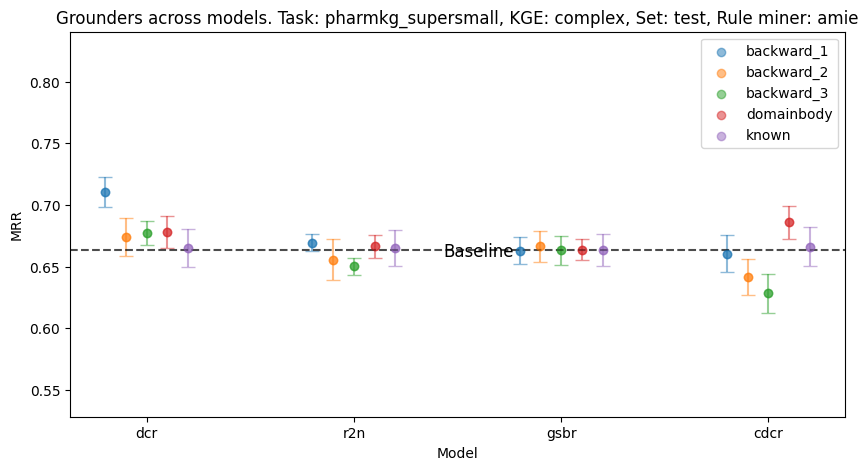

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  ncrl
Grounder     backward_1  backward_2  backward_3  domainbody   known
Model_name                                                         
cdcr             0.6684      0.6878      0.6943      0.6849  0.6635
dcr              0.6644      0.6754      0.6793      0.6764  0.6635
gsbr             0.6663      0.6630      0.6608      0.6631  0.6635
no_reasoner      0.6622      0.6603      0.6603      0.6699  0.6637
r2n              0.6687      0.6651      0.6695      0.6598  0.6653
<built-in method min of numpy.ndarray object at 0x000001D12E9ED290>


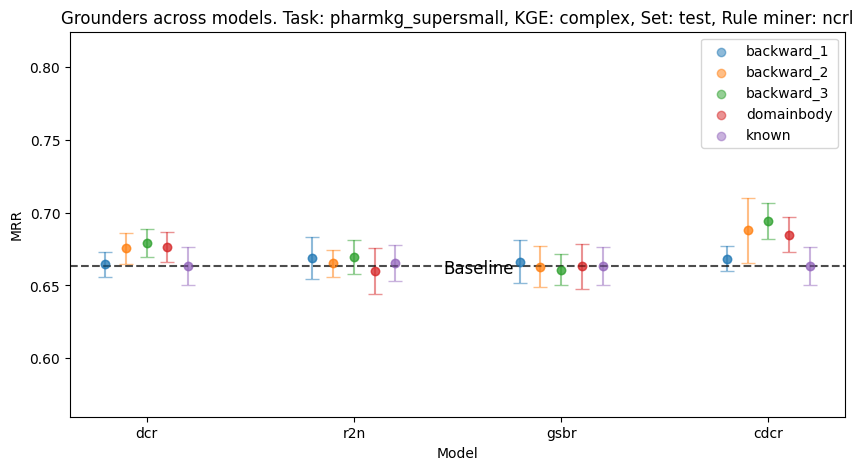

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  None
Grounder     backward_1   known
Model_name                     
cdcr                NaN  0.5719
dcr              0.6429  0.5691
gsbr             0.6366  0.5693
no_reasoner      0.5800  0.5800
r2n              0.6843  0.5690


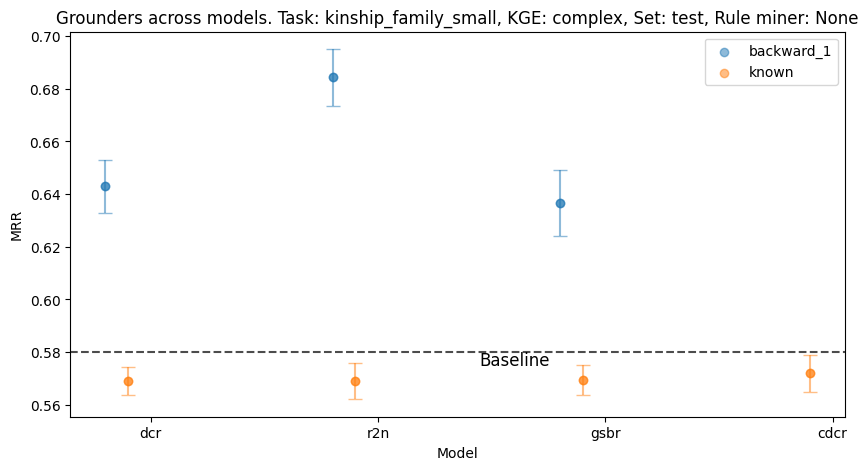

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  amie
Grounder     backward_1   known
Model_name                     
cdcr                NaN  0.5739
dcr              0.7159  0.5756
gsbr             0.7187  0.5761
no_reasoner      0.5800  0.5797
r2n              0.7760  0.5739


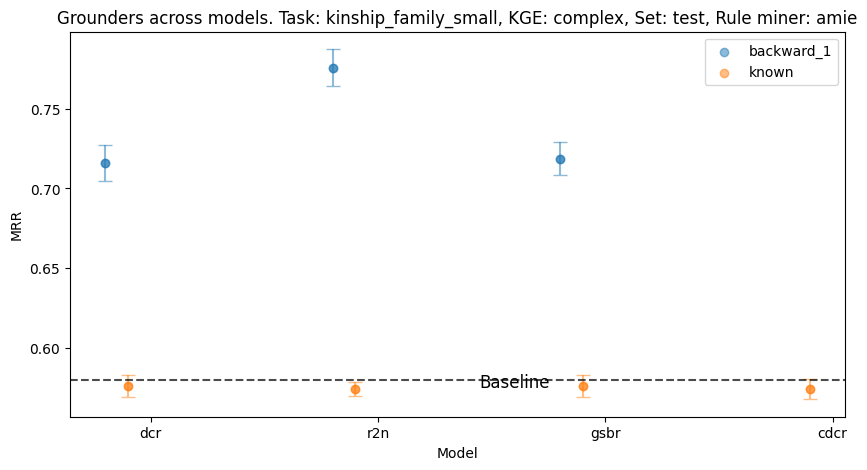

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  ncrl
Grounder     backward_1   known
Model_name                     
cdcr                NaN  0.5716
dcr              0.5776  0.5690
gsbr             0.5816  0.5690
no_reasoner      0.5800  0.5800
r2n              0.5784  0.5691


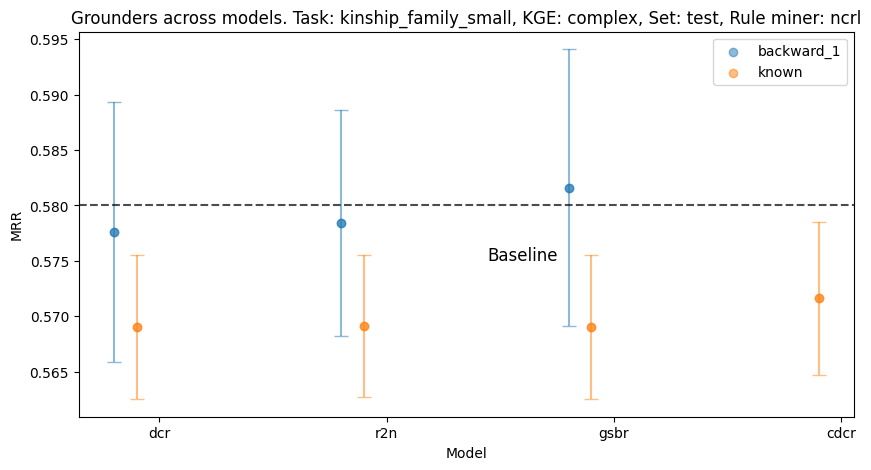

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  None
Grounder     backward_1  backward_2   known
Model_name                                 
cdcr             0.6066         NaN     NaN
dcr              0.6043      0.6013  0.5994
gsbr             0.6040      0.6019     NaN
no_reasoner      0.6043         NaN     NaN
r2n              0.6074      0.6073  0.6021


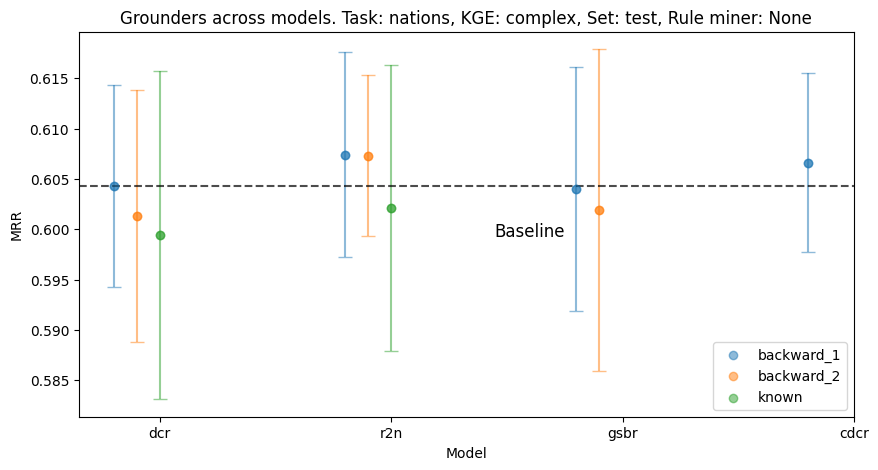

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  amie
Grounder     backward_1  backward_2   known
Model_name                                 
cdcr             0.6122         NaN     NaN
dcr              0.6038      0.6017  0.6011
gsbr             0.5970      0.6016     NaN
no_reasoner      0.6043         NaN     NaN
r2n              0.5945      0.6012  0.6003


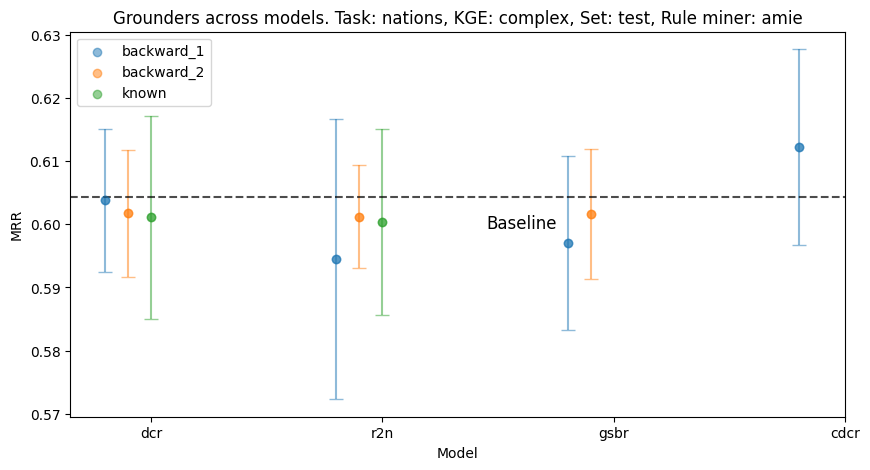

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  ncrl
Grounder     backward_1  backward_2   known
Model_name                                 
cdcr             0.5978         NaN     NaN
dcr              0.6077      0.6015  0.5994
gsbr             0.6022      0.5997     NaN
no_reasoner      0.6043         NaN     NaN
r2n              0.6030      0.6037  0.6021


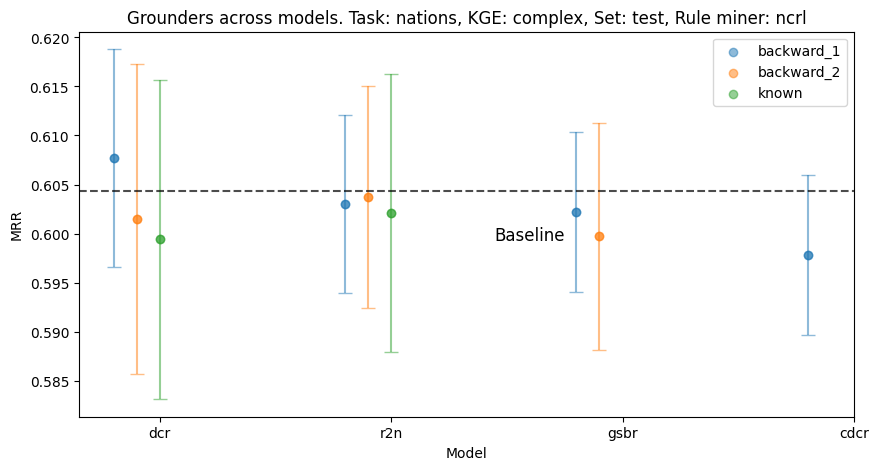

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  None
Grounder     backward_1  backward_2  backward_3  domainbody    full   known
Model_name                                                                 
cdcr             0.7550      0.7855      0.7855      0.7661  0.7680  0.7481
dcr              0.7615      0.7481      0.7481      0.7361  0.7557  0.7433
gsbr             0.7595      0.7582      0.7582      0.7601  0.7747  0.7473
no_reasoner      0.7414      0.7414      0.7414      0.7414  0.7414  0.7414
r2n              0.7382      0.7511      0.7511      0.7105  0.7741  0.7640
<built-in method min of numpy.ndarray object at 0x000001D12BFFF3F0>


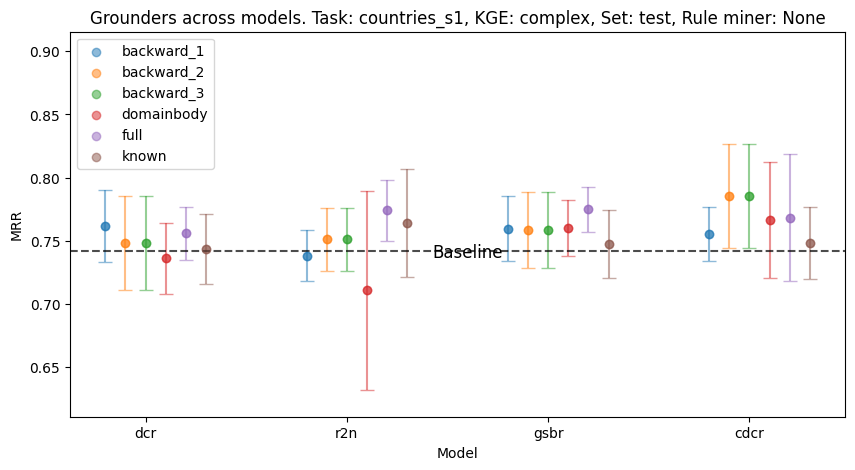

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  ncrl
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  None
Grounder     backward_1  backward_2  backward_3   known
Model_name                                             
cdcr             0.7609      0.7393      0.7585  0.7383
dcr              0.7735      0.7278      0.7384  0.7452
gsbr             0.7526      0.7388      0.7412  0.7317
no_reasoner      0.7256      0.7256      0.7256  0.7256
r2n              0.7972      0.7511      0.7585  0.7813
<built-in method min of numpy.ndarray object at 0x000001D12A6D4A50>


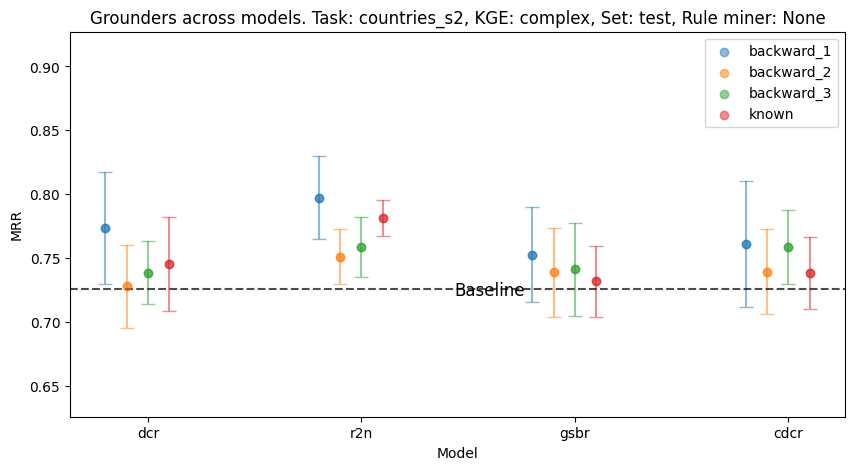

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  ncrl
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  None
Grounder     backward_1  backward_2  backward_3   known
Model_name                                             
cdcr             0.6120      0.6006      0.5948  0.5908
dcr              0.6123      0.5945      0.6061  0.6092
gsbr             0.6098      0.5896      0.6101  0.6094
no_reasoner      0.6078      0.6078      0.6078  0.6078
r2n              0.6120      0.6431      0.6229  0.6249
<built-in method min of numpy.ndarray object at 0x000001D12A6E9650>


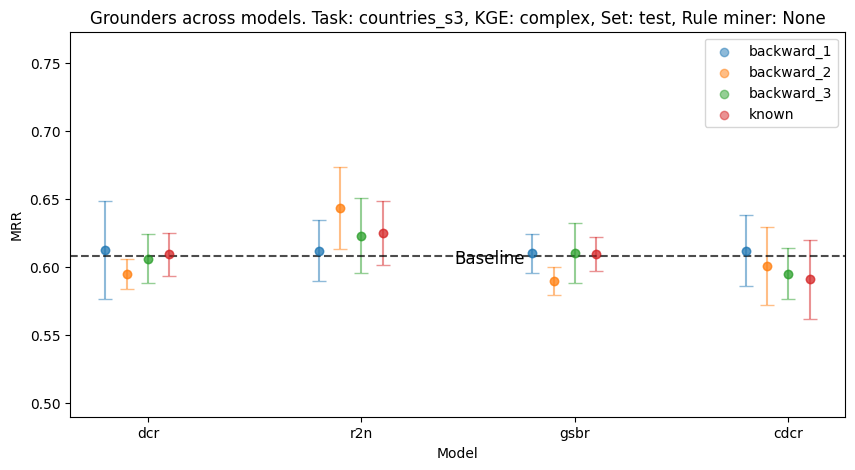

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  ncrl


In [305]:
# Table 1: rows:grounder, cols:Model, values: mrr
metric_names = {step+'_task_mrr':'MRR', 'Time':'Time (s)'}
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\figures\\"
os.makedirs(root_dir) if not os.path.exists(root_dir) else None
for task in tasks:
    for metric in ['test_task_mrr']:
        for KGE in KGEs:
            for rule_miner in rule_miners:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                if rule_miner not in dfs[task][KGE][metric].keys():
                    continue
                df_mean = dfs[task][KGE][metric][rule_miner]['mean']
                df_std = dfs[task][KGE][metric][rule_miner]['std']
                print(df_mean)
                # Remove no reasoner and include a line where it is written baseline
                plt.figure(figsize=(10,5))
                for i,grounder in enumerate(df_mean.loc[models_no_baseline].columns):
                    plt.scatter(np.arange(len(df_mean.loc[models_no_baseline].index))+0.1*i, df_mean.loc[models_no_baseline][grounder], label=grounder, alpha=0.5)
                    plt.errorbar(np.arange(len(df_mean.loc[models_no_baseline].index))+0.1*i, df_mean.loc[models_no_baseline][grounder], yerr=df_std.loc[models_no_baseline][grounder], fmt='o',capsize=5, alpha=0.5)
                if metric == step+'_task_mrr':
                    plt.axhline(y=df_mean.loc[baseline_model].mean(), color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                    plt.text(1.8, df_mean.loc[baseline_model].mean()-0.005, 'Baseline', color='black', fontsize=12, ha='center')
                    # print(df_mean.loc[baseline_model].values[0])
                plt.legend()
                plt.xticks(np.arange(len(df_mean.loc[models_no_baseline].index))+0.2, df_mean.loc[models_no_baseline].index.tolist(), rotation=0)
                plt.ylabel(metric_names[metric])
                plt.xlabel('Model')
                min = np.array([i for i in df_mean.loc[models].values.ravel() if i != np.nan])
                max = np.array([i for i in df_mean.loc[models].values.ravel() if i != np.nan])
                if min.min()<10:
                    print(min.min)
                    plt.ylim(min.min()-0.1,max.max()+0.13)
                plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}, Rule miner: {rule_miner}')
                plt.show()
                # SAVE THE FIGURE
                # if the directory does not exist, create it
                # plt.savefig(root_dir+'Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'_rule_'+rule_miner+'.png', dpi=300, bbox_inches='tight')  

In [251]:
# # Now do the plot of the average over the models
# for task in tasks:
#     for metric in ['test_task_mrr']:
#         for KGE in KGEs:
#             for rule_miner in ['None', 'amie', 'ncrl']:
#                 print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
#                 if rule_miner not in dfs[task][KGE][metric].keys():
#                     continue
#                 df_mean = dfs_avg[task][KGE][metric][rule_miner]['mean']
#                 print(df_mean)
#                 df_std = dfs_avg[task][KGE][metric][rule_miner]['std']
#                 # Remove no reasoner and include a line where it is written baseline
#                 plt.figure(figsize=(10,5))
#                 plt.scatter(np.arange(len(df_mean.index)),df_mean.values.flatten(), alpha=0.5)
#                 plt.errorbar(np.arange(len(df_mean.index)),df_mean.values.flatten(), yerr=df_std.values.flatten(), fmt='o',capsize=5, alpha=0.5)
#                 if metric == step+'_task_mrr':
#                     baseline = dfs[task][KGE][metric][rule_miner]['mean'].loc[baseline_model].mean()
#                     plt.axhline(y=baseline, color='black', linestyle='--', alpha=.7)   
#                     plt.text(1.8, baseline-0.005, 'Baseline', color='black', fontsize=12, ha='center')
#                 # in the xlabel put the names of the grounders
#                 plt.xticks(np.arange(len(df_mean.index)), df_mean.index.tolist(), rotation=0)
#                 plt.ylabel(metric_names[metric])
#                 min = np.array([i for i in df_mean.values.flatten() if i != np.nan])
#                 max = np.array([i for i in df_mean.values.flatten() if i != np.nan])
#                 print(min.min() is np.nan)
#                 if min.min()<1:
#                     print(min.min)
#                     plt.ylim(min.min()-0.1,max.max()+0.1)
#                 plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}, Rule miner: {rule_miner}')
#                 plt.show()
#                 # SAVE THE FIGURE
#                 # if the directory does not exist, create it
#                 # plt.savefig(root_dir+'Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'_rule_'+rule_miner+'.png', dpi=300, bbox_inches='tight')  

# By grounder instead

In [309]:
rows = 'Grounder'
cols = 'Model_name'
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
# create the dict dfs with 4 levels of keys: task, KGE, metric, rule_miner
dfs = nested_dict(4, dict)
for task in tasks:
    for metric in metrics:
        for KGE in KGEs:
            for rule_miner in rule_miners:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                # verify that the rule miner is within the values of Rule_Miner, else continue
                
                miners_available = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE)]['Rule_Miner'].unique()
                if (rule_miner not in miners_available):
                    print('Not available: rule_miner',rule_miner,'. Available: ',miners_available)
                    continue
                # filter the df
                results = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE) &(df['Rule_Miner'] == rule_miner) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
                # take only the columns grounder, model, test_task_mrr, test_concept_mrr
                results = results[[cols, rows, metric]]
                # Remove duplicates
                results = drop_duplicates_except_metric(results,cols,rows)
                # put the model_name as colums
                results = results.pivot(index=rows, columns=cols, values=metric)

                if metric == 'test_task_mrr':
                    # in the column no_reasoner, put the values of the column test_concept_mrr
                    substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) &(df['Rule_Miner'] == rule_miner) & (df['Model_name'] == baseline_model)][[cols,rows,baseline_metric]] #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                    # drop the duplicates , based on all the colums except for 'test_task_mrr'
                    substitute = drop_duplicates_except_metric(substitute,cols,rows)
                    substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                    # substitute the values in the table
                    if len(substitute) > 0:
                        results[baseline_model] = substitute[baseline_model] 
                    # print('\n\nresults',results)
                
                # obtain one df for the mean and one for the std
                results_mean, results_std = split_df(results)
                # append the results to dfs
                dfs[task][KGE][metric][rule_miner]['mean'] = results_mean
                dfs[task][KGE][metric][rule_miner]['std'] = results_std
                print('\n\nresults_mean',results_mean)
                
                # with open(csv_dir, 'a') as f:
                #     f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
                #     f.write('\n ') 
                # results.to_csv(csv_dir, mode='a', header=True)  
print(task, KGE, metric, rule_miner)
results_mean

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  None
Not available: rule_miner None . Available:  ['ncrl' 'amie']
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  amie


results_mean Model_name    cdcr     dcr    gsbr  no_reasoner     r2n
Grounder                                               
backward_1  0.6605  0.7105  0.6629       0.6622  0.6695
backward_2  0.6414  0.6738  0.6664       0.6603  0.6557
backward_3  0.6283  0.6776  0.6633       0.6603  0.6502
domainbody  0.6859  0.6782  0.6638       0.6699  0.6666
known       0.6663  0.6650  0.6635       0.6637  0.6651
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  ncrl


results_mean Model_name    cdcr     dcr    gsbr  no_reasoner     r2n
Grounder                                               
backward_1  0.6684  0.6644  0.6663       0.6622  0.6687
backward_2  0.6878  0.6754  0.6630       0.6603  0.6651
backward_3  0.6943  0.6793  0.6608       

Model_name,cdcr,dcr,gsbr,no_reasoner,r2n
Grounder,,,,,
backward_1,50.886968,46.529361,43.939657,17.973839,44.815323
backward_2,102.401642,91.183609,80.003281,15.174117,91.189728
backward_3,185.137829,137.851718,105.147630,18.977162,150.207439
known,33.698809,28.465808,21.553629,17.842463,23.772583


KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  None
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  amie
max:  0.7105 baseline:  0.663


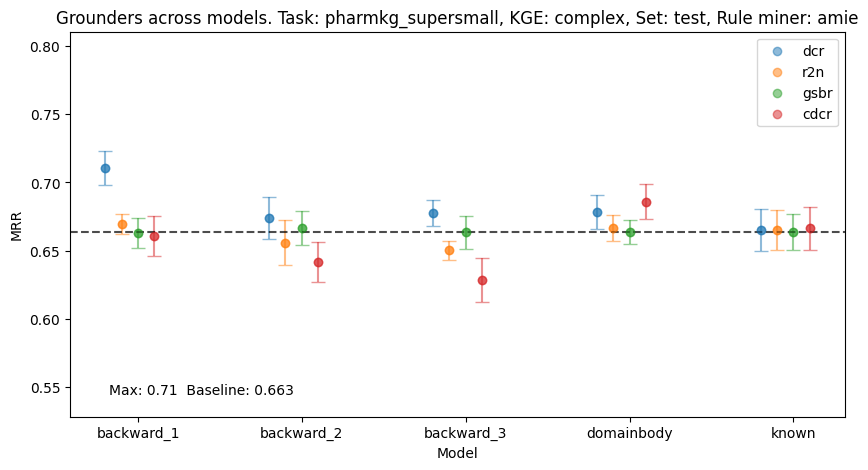

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  ncrl
max:  0.6943 baseline:  0.663


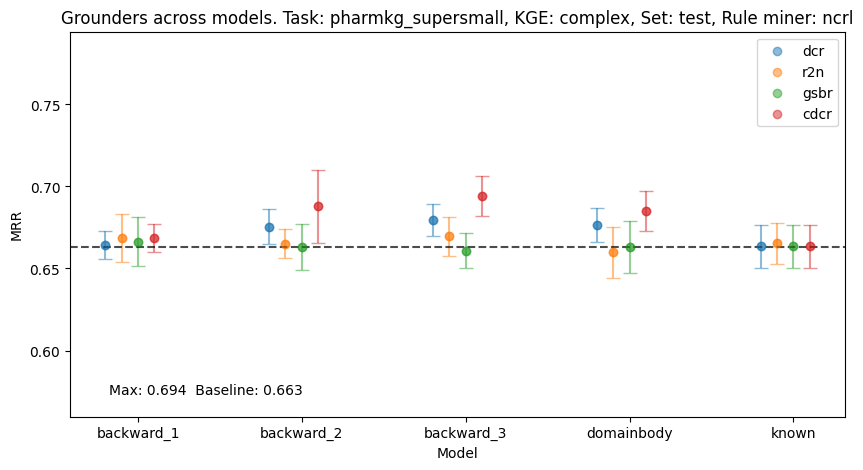

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  None
max:  0.6843 baseline:  0.58


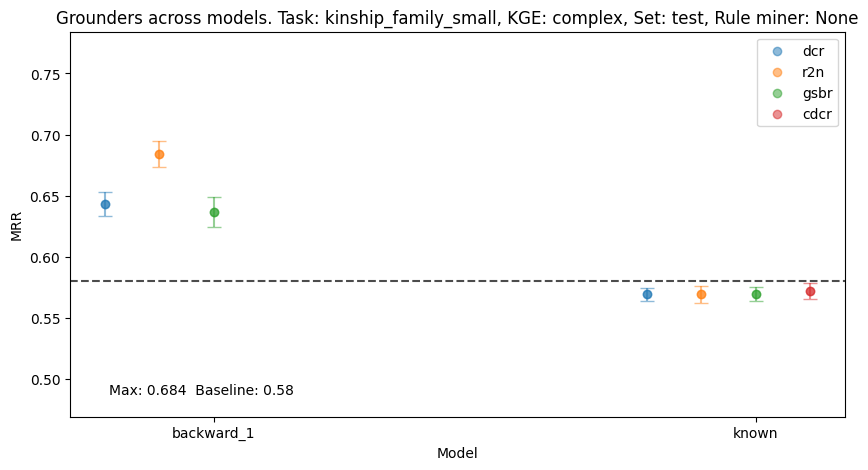

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  amie
max:  0.776 baseline:  0.58


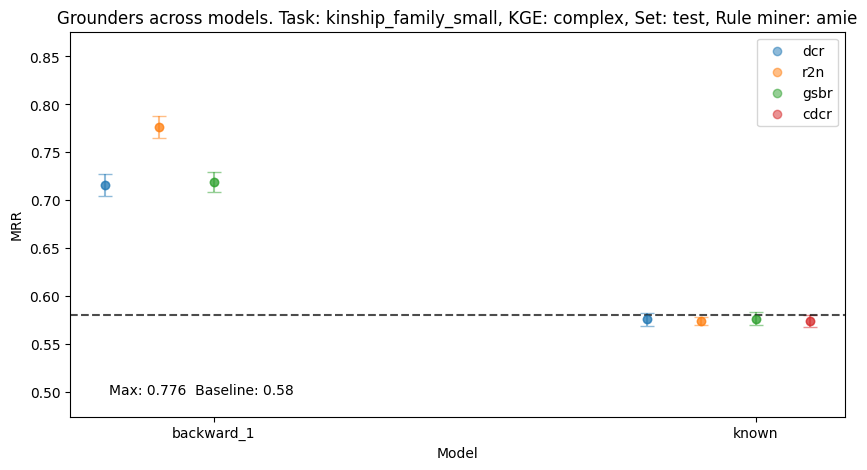

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  ncrl
max:  0.5816 baseline:  0.58


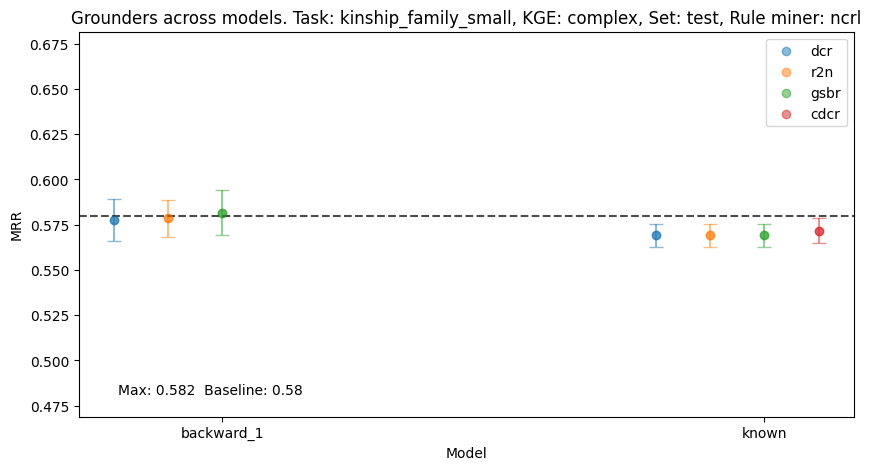

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  None
max:  0.6074 baseline:  0.604


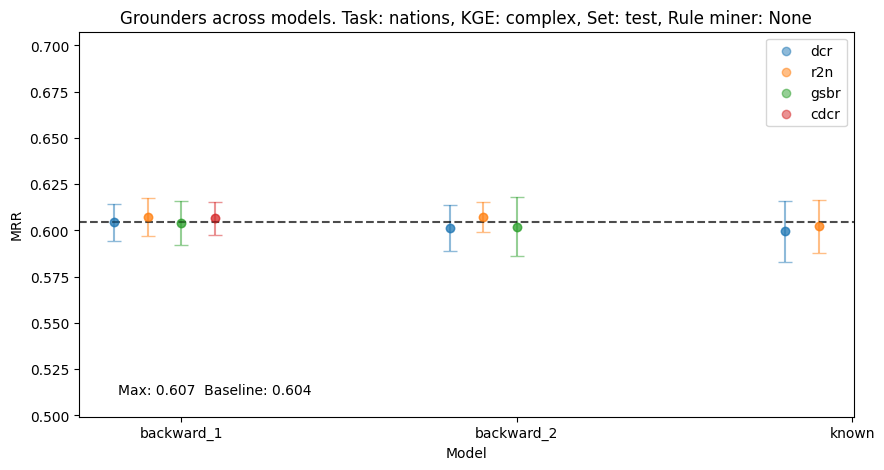

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  amie
max:  0.6122 baseline:  0.604


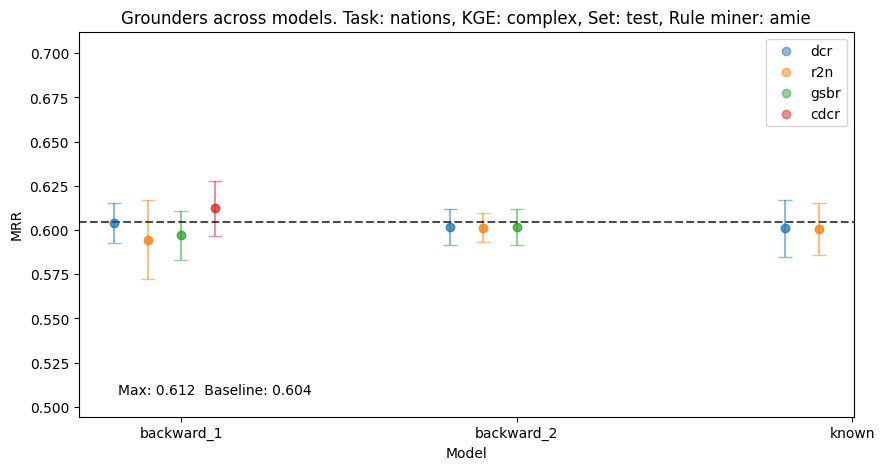

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  ncrl
max:  0.6077 baseline:  0.604


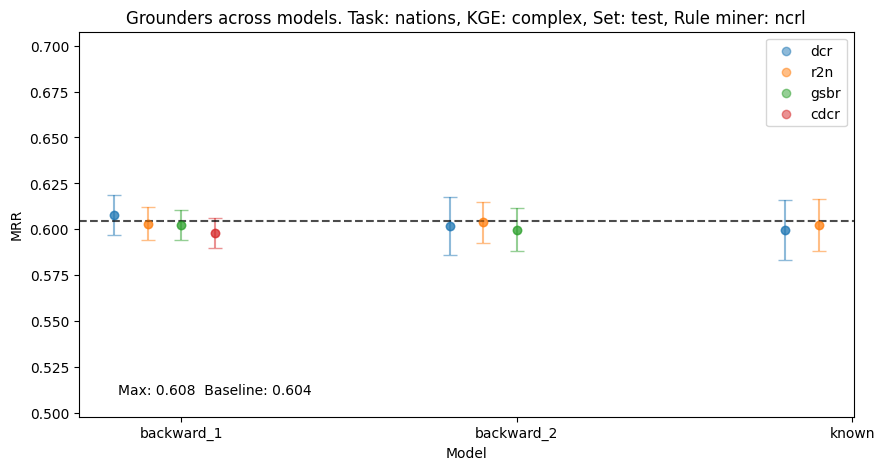

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  None
max:  0.7855 baseline:  0.741


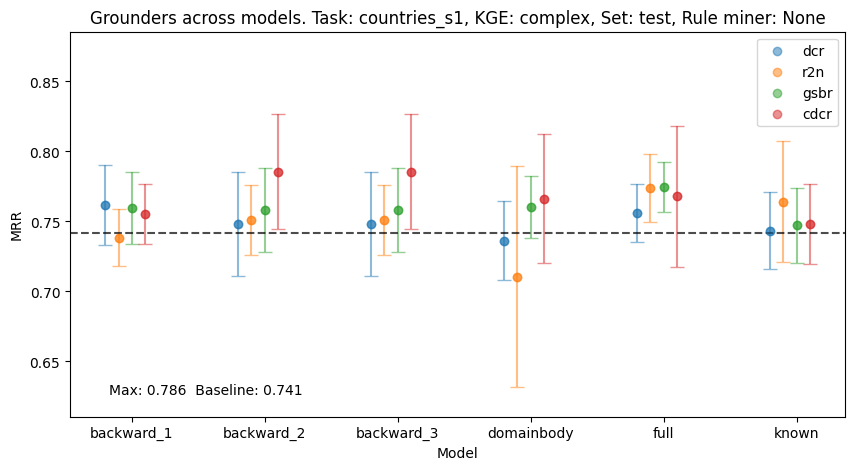

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  ncrl
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  None
max:  0.7972 baseline:  0.726


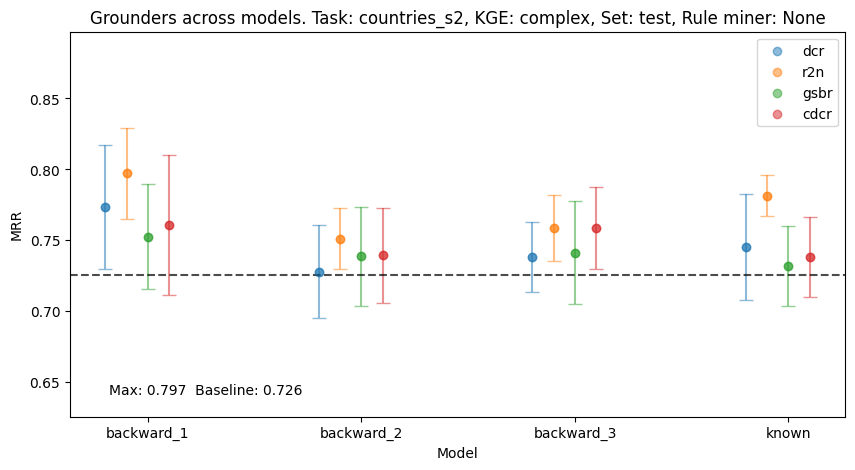

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  ncrl
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  None
max:  0.6431 baseline:  0.608


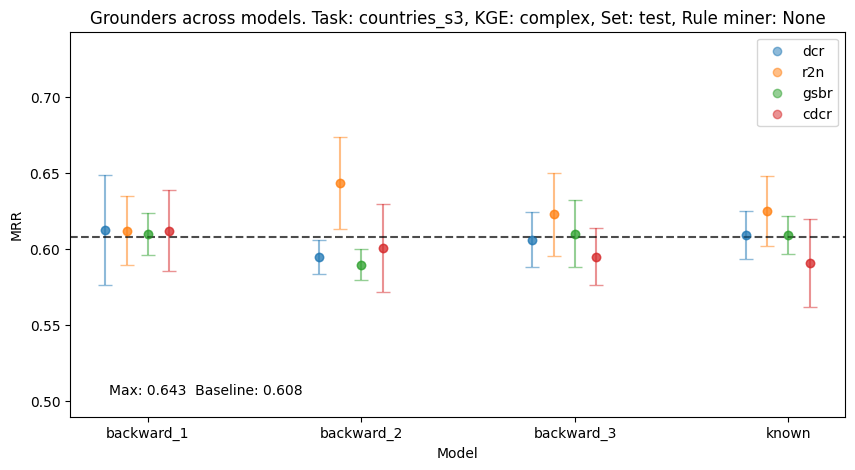

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  ncrl


In [340]:
# Table 1: rows:grounder, cols:Model, values: mrr
metric_names = {step+'_task_mrr':'MRR', 'Time':'Time (s)'}
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\figures\\"
os.makedirs(root_dir) if not os.path.exists(root_dir) else None
for task in tasks:
    for metric in ['test_task_mrr']:
        for KGE in KGEs:
            for rule_miner in rule_miners:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                if rule_miner not in dfs[task][KGE][metric].keys():
                    continue
                df_mean = dfs[task][KGE][metric][rule_miner]['mean']
                # print(df_mean)
                df_std = dfs[task][KGE][metric][rule_miner]['std']
                # Remove no reasoner and include a line where it is written baseline
                plt.figure(figsize=(10,5))
                for i,grounder in enumerate(df_mean[models_no_baseline].columns):
                    plt.scatter(np.arange(len(df_mean[models_no_baseline].index))+0.1*i, df_mean[models_no_baseline][grounder], label=grounder, alpha=0.5)
                    plt.errorbar(np.arange(len(df_mean[models_no_baseline].index))+0.1*i, df_mean[models_no_baseline][grounder], yerr=df_std[models_no_baseline][grounder], fmt='o',capsize=5, alpha=0.5)
                plt.legend()
                plt.xticks(np.arange(len(df_mean[models_no_baseline].index))+0.2, df_mean[models_no_baseline].index.tolist(), rotation=0)
                plt.ylabel(metric_names[metric])
                plt.xlabel('Model')
                min = np.array([i for i in df_mean[models].values.ravel() if not np.isnan(i)])  
                max = np.array([i for i in df_mean[models].values.ravel() if not np.isnan(i)]) 
                print('max: ',max.max(), 'baseline: ', np.round(df_mean[baseline_model].mean(),3))
                if min.min()<1:
                    plt.ylim(min.min()-0.1,max.max()+0.1)
                if metric == step+'_task_mrr':
                    plt.axhline(y=df_mean[baseline_model].mean(), color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                    # plt.text(1.8, df_mean[baseline_model].mean()-0.005, 'Baseline', color='black', fontsize=12, ha='right',clip_on=True)
                    plt.text(0.05, 0.05, 'Max: '+str(np.round(max.max(),3))+'  Baseline: '+str(np.round(df_mean[baseline_model].mean(),3)), transform=plt.gca().transAxes,
                            fontsize=10, verticalalignment='bottom', horizontalalignment='left')
                plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}, Rule miner: {rule_miner}')
                plt.show()
                # SAVE THE FIGURE
                # if the directory does not exist, create it
                # plt.savefig(root_dir+'Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'_rule_'+rule_miner+'.png', dpi=300, bbox_inches='tight')  

In [308]:
# # for every df of dfs, create a new df with the average over the models
# dfs_avg = nested_dict(4, dict)
# for task in tasks:
#     for metric in metrics:
#         for KGE in KGEs:
#             for rule_miner in rule_miners:
#                 for types in ['mean', 'std']:
#                     # print(types, 'KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
#                     if rule_miner not in dfs[task][KGE][metric].keys():
#                         continue
#                     dfi = dfs[task][KGE][metric][rule_miner][types].copy()
#                     # select from dfi the models that are in models_no_baseline
#                     dfi = dfi[models_no_baseline]
#                     dfi = dfi.mean(axis=0)
#                     dfi = pd.DataFrame(dfi)
#                     # set the name of the column as the metric
#                     dfi.columns = [metric]
#                     dfs_avg[task][KGE][metric][rule_miner][types] = dfi
#                     # print(dfi)
# dfi

- amie vs ncrl: amie is better
- models: no difference between models
- improvement over baseline: all datasets (kinship family, pharmkg, countries) excep nations 
    - in the rules generated, the grounder performance depends on the rules generator?
    - models: no best model
    - grounders: no best grounder overall, then go for back1 because of computing time. Do plot with axis inverted

